# Загрузка библиотек и моделей

In [2]:
import mmpose
from mmpose.apis import inference_topdown, init_model
from IPython.display import display, Image
import pathlib
import cv2
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from mmpose.registry import VISUALIZERS
from mmpose.structures import merge_data_samples
import tqdm.notebook as tqdm
from enum import Enum

In [8]:
dataset_path = pathlib.Path("hand dance 2")

In [3]:
def show_video(path: str, process_frame_func=None):
    video = cv2.VideoCapture(path)
    display_handle=display(None, display_id=True)
    
    try:
        while True:
            start = time.time()
            _, frame = video.read()
            if process_frame_func is not None:
                frame = process_frame_func(frame)
            _, frame = cv2.imencode('.jpeg', frame)
            end = time.time()
            fps = 1/(end-start)
            display_handle.update(Image(data=frame.tobytes()))
    except:
        pass
    finally:
        video.release()
        display_handle.update(None)

In [2]:
config_path = "C:/Users/maxim/p2025/mmpose/configs/hand_3d_keypoint/internet/interhand3d/internet_res50_4xb16-20e_interhand3d-256x256.py"

checkpoint_path = "https://download.openmmlab.com/mmpose/hand3d/internet/res50_intehand3dv1.0_all_256x256-42b7f2ac_20210702.pth"

model_hand = init_model(config_path, checkpoint_path, device="cpu")

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/hand3d/internet/res50_intehand3dv1.0_all_256x256-42b7f2ac_20210702.pth


C:\Users\maxim\anaconda3\envs\mmpose_cpu\lib\site-packages\mmpose\datasets\datasets\utils.py:102: UserWarning: The metainfo config file "configs/_base_/datasets/interhand3d.py" does not exist. A matched config file "C:\Users\maxim\anaconda3\envs\mmpose_cpu\lib\site-packages\mmpose\.mim\configs\_base_\datasets\interhand3d.py" will be used instead.
  warnings.warn(


In [3]:
config_path_1 =  r"C:\Users\maxim\p2025\mmpose\configs\body_2d_keypoint\topdown_heatmap\coco\td-hm_hrnet-w48_8xb32-210e_coco-256x192.py"
checkpoint_path_1 = "https://download.openmmlab.com/mmpose/top_down/hrnet/hrnet_w48_coco_256x192-b9e0b3ab_20200708.pth"

model_pose = init_model(config_path_1, checkpoint_path_1, device="cpu")
model_pose = model_pose.to("cpu")

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/top_down/hrnet/hrnet_w48_coco_256x192-b9e0b3ab_20200708.pth


C:\Users\maxim\anaconda3\envs\mmpose_cpu\lib\site-packages\mmpose\datasets\datasets\utils.py:102: UserWarning: The metainfo config file "configs/_base_/datasets/coco.py" does not exist. A matched config file "C:\Users\maxim\anaconda3\envs\mmpose_cpu\lib\site-packages\mmpose\.mim\configs\_base_\datasets\coco.py" will be used instead.
  warnings.warn(


In [9]:
# Выбор видео
CLASS = "3"
VIDEO_IDX = 4

video_path = list((dataset_path / CLASS).glob("*"))[VIDEO_IDX]
print(video_path)
video = cv2.VideoCapture(video_path)
_, img = video.read()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

hand dance 2\3\3914_10052025221521_6332f81a-2671-11ed-bb97-b474d352caff.mp4


# Эксперименты

In [7]:
show_video(video_path)

None

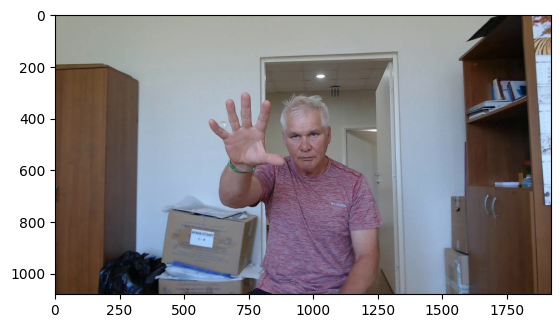

In [10]:
plt.imshow(img)

In [11]:
results = inference_topdown(model_pose, img)[0]

# Получить координату руки
keypoints = results.to_dict()["pred_instances"]["keypoints"][0]

RIGHT_HAND_IDX = 10
LEFT_HAND_IDX = 9

keypoints[RIGHT_HAND_IDX]

array([722.5, 527.5], dtype=float32)

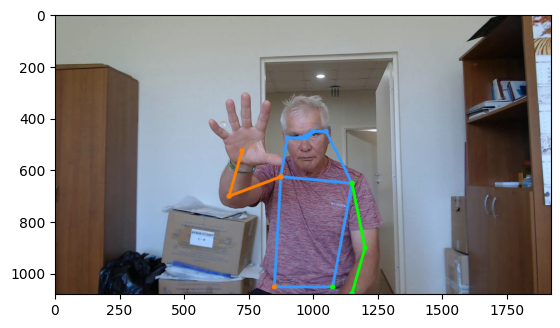

In [12]:
model_pose.cfg.visualizer.radius = sum(img.shape) // 300
model_pose.cfg.visualizer.alpha = 1.0
model_pose.cfg.visualizer.line_width = sum(img.shape) // 300

visualizer = VISUALIZERS.build(model_pose.cfg.visualizer)
visualizer.set_dataset_meta(model_pose.dataset_meta)

batch_results = inference_topdown(model_pose, img)
results = merge_data_samples(batch_results)

plt.imshow(
    visualizer.add_datasample(
            'result',
            img,
            data_sample=results,
            draw_gt=False,
            # draw_bbox=True,
            kpt_thr=0.5,
            # draw_heatmap=True,
            show_kpt_idx=True,
            # skeleton_style="mmpose",
            # show=True,
            # out_file="jopa.jpg",
    )
)

In [11]:
# Видео с pose estimation
def func(frame):
    batch_results = inference_topdown(model_pose, frame)
    results = merge_data_samples(batch_results)
    return visualizer.add_datasample(
        'result',
        frame,
        data_sample=results,
        draw_gt=False,
        # draw_bbox=True,
        kpt_thr=0.5,
        # draw_heatmap=True,
        show_kpt_idx=True,
        # skeleton_style="mmpose",
        # show=True,
        # out_file="jopa.jpg",
    )
show_video(video_path, func)

None

In [12]:
# Видео с вырезанием руки

HEIGHT = 500
WIDTH = 500

def func(frame):
    batch_results = inference_topdown(model_pose, frame)
    results = merge_data_samples(batch_results)

    keypoints = results.to_dict()["pred_instances"]["keypoints"][0]
    RIGHT_HAND_IDX = 10
    LEFT_HAND_IDX = 9
    x, y = keypoints[LEFT_HAND_IDX].astype(int)

    frame_cut = frame[
        y - HEIGHT // 2: y + HEIGHT // 2,
        x - WIDTH // 2: x + WIDTH // 2,
    ]
    return frame_cut
show_video(video_path, func)

None

In [8]:
dataset_path = pathlib.Path("hands_cut 2")

In [9]:
# Выбор видео

CLASS = "3"
VIDEO_IDX = 4

video_path = list((dataset_path / CLASS).glob("*"))[VIDEO_IDX]
print(video_path)
video = cv2.VideoCapture(video_path)
_, img = video.read()
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

hands_cut 2\3\3914_10052025221521_6332f81a-2671-11ed-bb97-b474d352caff.mp4


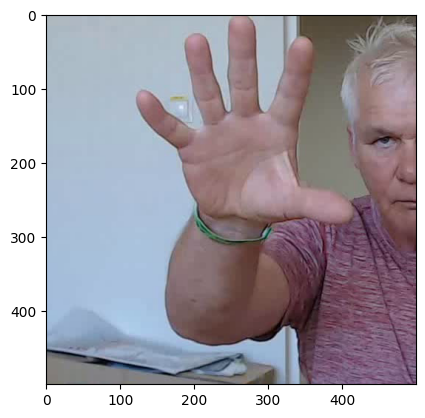

In [10]:
plt.imshow(img)

# Сохранение видео

In [2]:
def save_video(frames: np.ndarray, output_path: str) -> None:
    """
    frames - кадры видео, размерность n*h*w*3, n - кол-во кадров
    """
    n, h, w, c = frames.shape
    fourcc = cv2.VideoWriter_fourcc(*'MP4V')
    fps = 30
    frame_size = (w, h)
    out = cv2.VideoWriter(output_path, fourcc, fps, frame_size)
    for frame in frames:
        out.write(frame)
    out.release()

In [3]:
class Hand(Enum):
    LEFT = 1
    RIGHT = 2

    def get_keypoint_idx(self):
        return {Hand.LEFT: 9, Hand.RIGHT: 10}[self]

In [4]:
def pose_estimation(
    video_path: str,
) -> list:
    """Прогоняет pose estimation на видео и возвращает список с результатами по каждому кадру"""
    results = []
    pbar = tqdm.tqdm()
    video = cv2.VideoCapture(video_path)
    while True:
        ret, frame = video.read()
        if not ret:  # конец видео
            break

        batch_results = inference_topdown(model_pose, frame)
        results.append(merge_data_samples(batch_results))
        pbar.update(1)
    pbar.close()
    return results


def cut_hand_video(
    video_path: str,
    inference_results: list,
    hand: Hand,
    height: int = 500,
    width: int = 500,
) -> np.ndarray:
    """
    Вырезает руку из видео
    """
    video = cv2.VideoCapture(video_path)

    frames = []

    i = 0
    while True:
        ret, frame = video.read()
        if not ret:  # конец видео
            break

        results = inference_results[i]
        keypoints = results.to_dict()["pred_instances"]["keypoints"][0]
        
        x, y = keypoints[hand.get_keypoint_idx()].astype(int)

        frame_cut = frame[
            y - height // 2: y + height // 2,
            x - width // 2: x + width // 2,
        ]

        # Если кадр недостаточного размера, паддим
        h, w = frame_cut.shape[:2]
        pad_y = height - h
        pad_x = width - w
        frame_cut = np.pad(frame_cut, ((0, pad_y), (0, pad_x), (0, 0)))
        
        frames.append(frame_cut)
        i += 1
    return np.array(frames)

def get_moving_hand(
    inference_results: list,
) -> Hand:
    """Вычисляет руку, которая двигается по максимальной дисперсии координат"""
    left_hand_coords = []
    right_hand_coords = []
    for res in inference_results:
        keypoints = res.to_dict()["pred_instances"]["keypoints"][0]
        left_hand_coords.append(keypoints[Hand.LEFT.get_keypoint_idx()].astype(int))
        right_hand_coords.append(keypoints[Hand.RIGHT.get_keypoint_idx()].astype(int))
    left_hand_coords = np.array(left_hand_coords)
    right_hand_coords = np.array(right_hand_coords)
    left_std = left_hand_coords[:, 0].std() + left_hand_coords[:, 1].std()
    right_std = right_hand_coords[:, 0].std() + right_hand_coords[:, 1].std()
    if left_std > right_std:
        return Hand.LEFT
    return Hand.RIGHT

In [31]:
pip install ipywidgets

   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.2 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.2 MB 1.7 MB/s eta 0:00:01
   ---------------------------- ----------- 1.6/2.2 MB 2.9 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 3.5 MB/s eta 0:00:00

   -------------------------- ------------- 2/3 [ipywidgets]
   ---------------------------------------- 3/3 [ipywidgets]

Note: you may need to restart the kernel to use updated packages.


In [32]:
jupyter nbextension enable --py widgetsnbextension --sys-prefix
jupyter nbextension install --py widgetsnbextension --sys-prefix

SyntaxError: invalid syntax (1188951427.py, line 1)

In [16]:
inference_results = pose_estimation(video_path)

0it [00:00, ?it/s]

In [18]:
hand = get_moving_hand(inference_results)

frames = cut_hand_video(
    video_path,
    inference_results,
    hand=hand,
)

In [19]:
frames.shape

(366, 500, 500, 3)

In [19]:
save_video(frames, "out.mp4")

# Обрезание всех видео

In [9]:
dataset_path = pathlib.Path("hand dance 1")
cut_dataset_path = pathlib.Path("hands_cut 1")
cut_dataset_path.mkdir(exist_ok=True)

classes_folders = ["0", "1", "2", "3"]

In [10]:
# запуск 1 части
for cls in classes_folders:
    cls_folder = dataset_path / cls
    out_cls_folder = cut_dataset_path / cls
    out_cls_folder.mkdir(exist_ok=True)

    for video_path in cls_folder.glob("*"):
        out_video_path = out_cls_folder / video_path.name
        
        inference_results = pose_estimation(video_path)

        hand = get_moving_hand(inference_results)

        frames = cut_hand_video(
            video_path,
            inference_results,
            hand=hand,
        )

        save_video(frames, out_video_path)

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [20]:
dataset_path = pathlib.Path("hand dance 2")
cut_dataset_path = pathlib.Path("hands_cut 2")
cut_dataset_path.mkdir(exist_ok=True)

classes_folders = ["0", "1", "2", "3"]

In [ ]:
# запуск 2 части
for cls in classes_folders:
    cls_folder = dataset_path / cls
    out_cls_folder = cut_dataset_path / cls
    out_cls_folder.mkdir(exist_ok=True)

    for video_path in cls_folder.glob("*"):
        out_video_path = out_cls_folder / video_path.name
        
        inference_results = pose_estimation(video_path)

        hand = get_moving_hand(inference_results)

        frames = cut_hand_video(
            video_path,
            inference_results,
            hand=hand,
        )

        save_video(frames, out_video_path)

# Предсказание рук

In [18]:
def hand_estimation(
    video_path: str,
) -> list:
    """Прогоняет hand estimation на видео и возвращает список с результатами по каждому кадру"""
    results = []
    pbar = tqdm.tqdm()
    video = cv2.VideoCapture(video_path)
    while True:
        ret, frame = video.read()
        if not ret:  # конец видео
            break

        batch_results = inference_topdown(model_hand, frame)
        results.append(merge_data_samples(batch_results))
        pbar.update(1)
    pbar.close()
    return results

In [19]:
res = hand_estimation(list((cut_dataset_path / "1").glob("*"))[0])

0it [00:00, ?it/s]

In [21]:
res[0]

<PoseDataSample(

    META INFORMATION
    input_center: array([250., 250.], dtype=float32)
    input_size: (256, 256)
    pad_shape: (256, 256)
    batch_input_shape: (256, 256)
    flip_indices: [21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
    img_shape: (500, 500)
    input_scale: array([625., 625.], dtype=float32)
    img_path: None

    DATA FIELDS
    pred_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            bbox_scores: array([1.], dtype=float32)
            bboxes: array([[  0.,   0., 500., 500.]], dtype=float32)
            rel_root_depth: array([18.60199], dtype=float32)
            keypoints_visible: array([[186.14493   , 200.06207   , 188.7355    , 185.45593   ,
                         99.86051   , 162.11852   , 188.3763    , 221.34052   ,
                         66.05002   , 105.492744  , 201.93648   , 2

# Извлечение 3D точек

In [3]:
cut_dataset_path = pathlib.Path("hands_cut")

In [4]:
# Путь к модели для 3D руки
hand_config_path = "C:/Users/maxim/p2025/mmpose/configs/hand_3d_keypoint/internet/interhand3d/internet_res50_4xb16-20e_interhand3d-256x256.py"
hand_checkpoint = "https://download.openmmlab.com/mmpose/hand3d/internet/res50_intehand3dv1.0_all_256x256-42b7f2ac_20210702.pth"
model_hand = init_model(hand_config_path, hand_checkpoint, device="cpu")

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/hand3d/internet/res50_intehand3dv1.0_all_256x256-42b7f2ac_20210702.pth


C:\Users\maxim\anaconda3\envs\mmpose_cpu\lib\site-packages\mmpose\datasets\datasets\utils.py:102: UserWarning: The metainfo config file "configs/_base_/datasets/interhand3d.py" does not exist. A matched config file "C:\Users\maxim\anaconda3\envs\mmpose_cpu\lib\site-packages\mmpose\.mim\configs\_base_\datasets\interhand3d.py" will be used instead.
  warnings.warn(


In [5]:
def hand_estimation(video_path: str, model) -> list:
    """Прогоняет hand estimation на видео и возвращает список результатов (по кадрам)."""
    results = []
    pbar = tqdm.tqdm()
    video = cv2.VideoCapture(str(video_path))
    while True:
        ret, frame = video.read()
        if not ret:
            break
        batch_results = inference_topdown(model, frame)
        merged = merge_data_samples(batch_results)
        results.append(merged)
        pbar.update(1)
    pbar.close()
    return results


In [6]:
def extract_3d_keypoints(results: list) -> np.ndarray:
    """
    Извлекает 3D ключевые точки одной (реальной) руки из результатов.
    Работает с sample.pred_instances.keypoints, которые уже в NumPy.
    """
    keypoints_all = []
    for sample in results:
        try:
            kp3d = sample.pred_instances.keypoints[0]  # уже NumPy, shape (42, 3)

            left = kp3d[:21]
            right = kp3d[21:]

            # Выбираем руку с большим числом ненулевых координат
            left_valid = np.sum(~np.isnan(left))
            right_valid = np.sum(~np.isnan(right))

            if right_valid >= left_valid:
                keypoints_all.append(right)
            else:
                keypoints_all.append(left)

        except Exception as e:
            print(f"Ошибка в кадре: {e}")
            keypoints_all.append(np.full((21, 3), np.nan))
    return np.array(keypoints_all)


In [7]:
def save_keypoints_to_npy(keypoints3d: np.ndarray, out_path: str):
    np.save(out_path, keypoints3d)

In [8]:
def save_keypoints_to_csv(keypoints3d: np.ndarray, out_path: str):
    """
    Сохраняет 3D ключевые точки в .csv формате. Каждая строка — один кадр.
    Формат: frame,x_0,y_0,z_0,...,x_20,y_20,z_20
    """
    n_frames, n_joints, _ = keypoints3d.shape
    rows = []
    for frame_idx in range(n_frames):
        row = {"frame": frame_idx}
        for joint_idx in range(n_joints):
            x, y, z = keypoints3d[frame_idx, joint_idx]
            row[f"x_{joint_idx}"] = x
            row[f"y_{joint_idx}"] = y
            row[f"z_{joint_idx}"] = z
        rows.append(row)
    df = pd.DataFrame(rows)
    df.to_csv(out_path, index=False)


In [9]:
def process_video(video_path: str, output_dir: str, model) -> None:
    """
    Обрабатывает видео: извлекает 3D ключевые точки и сохраняет их.
    """
    output_dir = pathlib.Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    print(f"Обработка: {video_path}")
    results = hand_estimation(video_path, model)
    keypoints3d = extract_3d_keypoints(results)

    base_name = pathlib.Path(video_path).stem
    npy_path = output_dir / f"{base_name}_3dkeypoints.npy"
    csv_path = output_dir / f"{base_name}_3dkeypoints.csv"

    save_keypoints_to_npy(keypoints3d, npy_path)
    save_keypoints_to_csv(keypoints3d, csv_path)
    print(f"Сохранено: {npy_path} и {csv_path}")


In [12]:
res = hand_estimation("hands_cut/1/10107_11052025091843_edc3daee-2452-11ed-98bc-e82aea2c97f4.mp4", model_hand)

sample = res[0]
print(sample)

0it [00:00, ?it/s]

<PoseDataSample(

    META INFORMATION
    input_center: array([250., 250.], dtype=float32)
    input_scale: array([625., 625.], dtype=float32)
    batch_input_shape: (256, 256)
    img_shape: (500, 500)
    input_size: (256, 256)
    flip_indices: [21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
    img_path: None
    pad_shape: (256, 256)

    DATA FIELDS
    gt_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            bbox_scales: array([[625., 625.]], dtype=float32)
            bbox_scores: array([1.], dtype=float32)
            bboxes: array([[  0.,   0., 500., 500.]], dtype=float32)
        ) at 0x20d27965f30>
    pred_instances: <InstanceData(
        
            META INFORMATION
        
            DATA FIELDS
            rel_root_depth: array([-55.97651], dtype=float32)
            hand_type: array([[1, 1]])
        

In [13]:
keypoints3d = sample.pred_instances.keypoints
print("Shape:", keypoints3d.shape)

Shape: (1, 42, 3)


In [24]:
video_path = "hands_cut/1/128_10052025191527_05f7ade2-c544-11ec-9d27-e82aea2c97f4.mp4"
output_dir = "output_keypoints"
process_video(video_path, output_dir, model_hand)

🔍 Обработка: hands_cut/1/128_10052025191527_05f7ade2-c544-11ec-9d27-e82aea2c97f4.mp4


0it [00:00, ?it/s]

✅ Сохранено: output_keypoints\128_10052025191527_05f7ade2-c544-11ec-9d27-e82aea2c97f4_3dkeypoints.npy и output_keypoints\128_10052025191527_05f7ade2-c544-11ec-9d27-e82aea2c97f4_3dkeypoints.csv


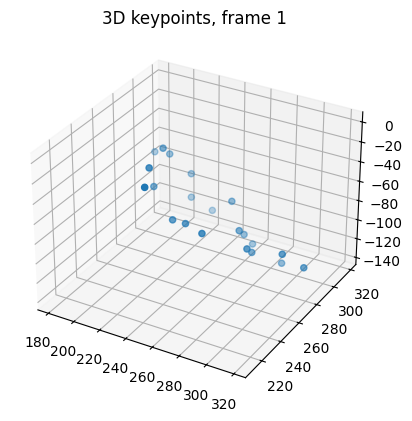

In [27]:
data = np.load("output_keypoints/128_10052025191527_05f7ade2-c544-11ec-9d27-e82aea2c97f4_3dkeypoints.npy")

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

frame_idx = 1  # любой кадр
xyz = data[frame_idx]
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2])
ax.set_title(f"3D keypoints, frame {frame_idx}")
plt.show()


In [10]:
import cv2
import numpy as np

def draw_2d_keypoints(frame, keypoints):
    """
    Отображает 21 ключевую точку на кадре
    """
    for x, y, z in keypoints:
        if not np.isnan(x) and not np.isnan(y):
            cv2.circle(frame, (int(x), int(y)), 4, (0, 255, 0), -1)
    return frame


def visualize_keypoints_on_video(video_path: str, keypoints_array: np.ndarray):
    cap = cv2.VideoCapture(video_path)
    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret or frame_idx >= len(keypoints_array):
            break

        keypoints = keypoints_array[frame_idx]
        frame = draw_2d_keypoints(frame, keypoints)

        cv2.imshow("Keypoints Overlay", frame)
        if cv2.waitKey(20) & 0xFF == 27:  # ESC to quit
            break

        frame_idx += 1

    cap.release()
    cv2.destroyAllWindows()


In [31]:
video_path = "hands_cut/1/128_10052025191527_05f7ade2-c544-11ec-9d27-e82aea2c97f4.mp4"
keypoints_path = "output_keypoints/128_10052025191527_05f7ade2-c544-11ec-9d27-e82aea2c97f4_3dkeypoints.npy"

keypoints3d = np.load(keypoints_path)
visualize_keypoints_on_video(video_path, keypoints3d)

In [12]:
def save_video_with_keypoints(video_path: str, keypoints_array: np.ndarray, out_path: str):
    cap = cv2.VideoCapture(video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)

    # Настраиваем видео-сохранялку
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")  # или 'XVID'
    out = cv2.VideoWriter(out_path, fourcc, fps, (width, height))

    frame_idx = 0
    while True:
        ret, frame = cap.read()
        if not ret or frame_idx >= len(keypoints_array):
            break

        keypoints = keypoints_array[frame_idx]
        frame = draw_2d_keypoints(frame, keypoints)

        out.write(frame)
        frame_idx += 1

    cap.release()
    out.release()
    print(f"🎞️ Видео сохранено: {out_path}")


In [13]:
def draw_2d_keypoints(frame, keypoints):
    for x, y, z in keypoints:
        if not np.isnan(x) and not np.isnan(y):
            cv2.circle(frame, (int(x), int(y)), 4, (0, 255, 0), -1)
    return frame


In [17]:
video_path = r"C:\Users\maxim\p2025\hands_cut\0\10_10052025180232_4be19464-2205-11ed-b24c-b469216ca443.mp4"
keypoints_path = r"C:\Users\maxim\p2025\output_keypoints\0\10_10052025180232_4be19464-2205-11ed-b24c-b469216ca443_3dkeypoints.npy"
out_video_path = "output_keypoints/10_10052025180232_keypoints_overlay.mp4"

keypoints3d = np.load(keypoints_path)
# visualize_keypoints_on_video(video_path, keypoints3d)
save_video_with_keypoints(video_path, keypoints3d, out_video_path)

🎞️ Видео сохранено: output_keypoints/10_10052025180232_keypoints_overlay.mp4


In [34]:
video_path = "hands_cut/1/128_10052025191527_05f7ade2-c544-11ec-9d27-e82aea2c97f4.mp4"
keypoints_path = "output_keypoints/128_10052025191527_05f7ade2-c544-11ec-9d27-e82aea2c97f4_3dkeypoints.npy"
out_video_path = "output_keypoints/128_keypoints_overlay.mp4"

keypoints3d = np.load(keypoints_path)
save_video_with_keypoints(video_path, keypoints3d, out_video_path)

🎞️ Видео сохранено: output_keypoints/128_keypoints_overlay.mp4


In [11]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


Пробуем

In [ ]:
import os
import pandas as pd
from tqdm import tqdm

video_dir = "hands_cut"
output_dir = "keypoints_csv"
os.makedirs(output_dir, exist_ok=True)

def hand_estimation(video_path: str, model) -> list:
    """Прогоняет hand estimation на видео и возвращает список с результатами по кадрам"""
    results = []
    video = cv2.VideoCapture(video_path)
    pbar = tqdm(total=int(video.get(cv2.CAP_PROP_FRAME_COUNT)), desc=os.path.basename(video_path))
    while True:
        ret, frame = video.read()
        if not ret:
            break
        batch_results = inference_topdown(model, frame)
        results.append(merge_data_samples(batch_results))
        pbar.update(1)
    pbar.close()
    video.release()
    return results

def save_keypoints_to_csv(results: list, out_path: str):
    rows = []
    for frame_idx, sample in enumerate(results):
        keypoints = sample.pred_instances.keypoints  # shape (1, 42, 3)
        kps = keypoints[0]  # (42, 3)
        row = {"frame": frame_idx}
        for i, (x, y, z) in enumerate(kps):
            row[f"x_{i}"] = x
            row[f"y_{i}"] = y
            row[f"z_{i}"] = z
        rows.append(row)
    df = pd.DataFrame(rows)
    df.to_csv(out_path, index=False)

# Обход всех видео в подпапках и сохранение ключевых точек
for class_folder in os.listdir(video_dir):
    class_path = os.path.join(video_dir, class_folder)
    if os.path.isdir(class_path):
        for video_file in os.listdir(class_path):
            if video_file.endswith(".mp4"):
                video_path = os.path.join(class_path, video_file)
                print(f"Обрабатываю {video_path}...")
                results = hand_estimation(video_path, model_hand)
                csv_name = f"{class_folder}_{video_file.replace('.mp4', '')}.csv"
                out_csv_path = os.path.join(output_dir, csv_name)
                save_keypoints_to_csv(results, out_csv_path)
                print(f"Сохранено: {out_csv_path}")

Обрабатываю hands_cut\0\100_10052025191422_0315b142-246b-11ed-a221-e82aea2c97f4.mp4...


100_10052025191422_0315b142-246b-11ed-a221-e82aea2c97f4.mp4: 100%|███████████████████| 279/279 [01:23<00:00,  3.33it/s]


Сохранено: keypoints_csv\0_100_10052025191422_0315b142-246b-11ed-a221-e82aea2c97f4.csv
Обрабатываю hands_cut\0\10178_11052025093016_f2c94ce2-6a49-11ed-ab19-e82aea2c97f4.mp4...


10178_11052025093016_f2c94ce2-6a49-11ed-ab19-e82aea2c97f4.mp4: 100%|█████████████████| 367/367 [01:57<00:00,  3.13it/s]


Сохранено: keypoints_csv\0_10178_11052025093016_f2c94ce2-6a49-11ed-ab19-e82aea2c97f4.csv
Обрабатываю hands_cut\0\1023_10052025200029_968a1da4-aa89-11ec-be35-e82aea2c97f4.mp4...


...

10305_11052025095054_faedcf64-5449-11ed-b330-e82aea2c97f4.mp4: 100%|█████████████████| 316/316 [01:54<00:00,  2.77it/s]


Сохранено: keypoints_csv\0_10305_11052025095054_faedcf64-5449-11ed-b330-e82aea2c97f4.csv
Обрабатываю hands_cut\0\1073_10052025200221_9ddddde2-64c3-11ed-b566-e82aea2c97f4.mp4...


1073_10052025200221_9ddddde2-64c3-11ed-b566-e82aea2c97f4.mp4: 100%|██████████████████| 260/260 [02:27<00:00,  1.76it/s]


Сохранено: keypoints_csv\0_1073_10052025200221_9ddddde2-64c3-11ed-b566-e82aea2c97f4.csv
Обрабатываю hands_cut\0\1078_10052025200234_9e99509c-2dd4-11ed-b513-e82aea2c97f4.mp4...


1078_10052025200234_9e99509c-2dd4-11ed-b513-e82aea2c97f4.mp4:  18%|███▍               | 44/243 [00:23<01:45,  1.89it/s]

In [32]:
all_results = {}

for video_file in video_files:
    video_path = os.path.join(video_dir, video_file)
    
    # Инференс 3D модели
    res = hand_estimation(video_path, model_hand)
    
    # Извлекаем ключевые точки на каждый кадр
    keypoints_per_frame = []
    for s in res:
        keypoints = s.pred_instances.keypoints  # ← уже numpy массив
        if keypoints is not None and len(keypoints) > 0:
            keypoints_per_frame.append(keypoints[0])  # (42, 3)
        else:
            keypoints_per_frame.append(np.full((42, 3), np.nan))  # если пусто
    
    keypoints_array = np.array(keypoints_per_frame)  # → shape: (n_frames, 42, 3)
    all_results[video_file] = keypoints_array


In [33]:
for video_file, keypoints_array in all_results.items():
    out_path = f"keypoints_npy/{video_file.replace('.mp4', '.npy')}"
    np.save(out_path, keypoints_array)

In [36]:
import pandas as pd
import os

os.makedirs("keypoints_csv", exist_ok=True)

for video_file, keypoints_array in all_results.items():
    print(f"Saving {video_file} with shape {keypoints_array.shape}")
    rows = []
    for frame_idx, kps in enumerate(keypoints_array):
        row = {"frame": frame_idx}
        for i, (x, y, z) in enumerate(kps):
            row[f"x_{i}"] = x
            row[f"y_{i}"] = y
            row[f"z_{i}"] = z
        rows.append(row)

    df = pd.DataFrame(rows)
    out_csv = f"keypoints_csv/{video_file.replace('.mp4', '.csv')}"
    df.to_csv(out_csv, index=False)
    print(f"Saved to {out_csv}")


In [35]:
print("all_results keys:", all_results.keys())
for video_file, keypoints_array in all_results.items():
    print(f"{video_file}: shape = {keypoints_array.shape}")


all_results keys: dict_keys([])


# Эксперимент для 1 видео (Обрезать видео + получить точки)

In [108]:
import mmpose
from mmpose.apis import inference_topdown, init_model
from IPython.display import display, Image
import pathlib
import cv2
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from mmpose.registry import VISUALIZERS
from mmpose.structures import merge_data_samples
import tqdm.notebook as tqdm
from enum import Enum

In [61]:
import cv2
import tqdm
import pathlib
import numpy as np
import pandas as pd
from mmpose.apis import init_model, inference_topdown

In [98]:
hand_config_path = "C:/Users/maxim/p2025/mmpose/configs/hand_3d_keypoint/internet/interhand3d/internet_res50_4xb16-20e_interhand3d-256x256.py"
hand_checkpoint = "https://download.openmmlab.com/mmpose/hand3d/internet/res50_intehand3dv1.0_all_256x256-42b7f2ac_20210702.pth"
model_hand = init_model(hand_config_path, hand_checkpoint, device="cpu")

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/hand3d/internet/res50_intehand3dv1.0_all_256x256-42b7f2ac_20210702.pth


In [99]:
# === Обработка видео и извлечение точек ===
def hand_estimation(video_path: str, model) -> list:
    results = []
    video = cv2.VideoCapture(str(video_path))
    pbar = tqdm.tqdm()
    while True:
        ret, frame = video.read()
        if not ret:
            break
        batch_results = inference_topdown(model, frame)
        if batch_results:
            results.append(batch_results[0])  # Берем только первую руку
        else:
            results.append(None)
        pbar.update(1)
    video.release()
    pbar.close()
    return results

In [100]:
def extract_3d_keypoints(results: list) -> np.ndarray:
    keypoints_all = []
    for sample in results:
        if sample is None:
            keypoints_all.append(np.full((21, 3), np.nan))
            continue

        try:
            kp3d = sample.pred_instances.keypoints[0]  # shape (42, 3)
            left = kp3d[:21]
            right = kp3d[21:]


            left_valid = np.sum(~np.isnan(left))
            right_valid = np.sum(~np.isnan(right))

            keypoints_all.append(right if right_valid >= left_valid else left)
        except Exception:
            keypoints_all.append(np.full((21, 3), np.nan))
    return np.array(keypoints_all)

In [102]:
def save_keypoints(keypoints3d: np.ndarray, npy_path: str, csv_path: str):
    np.save(npy_path, keypoints3d)

    rows = []
    for i, frame in enumerate(keypoints3d):
        row = {"frame": i}
        for j, (x, y, z) in enumerate(frame):
            row[f"x_{j}"] = x
            row[f"y_{j}"] = y
            row[f"z_{j}"] = z
        rows.append(row)
    pd.DataFrame(rows).to_csv(csv_path, index=False)

In [104]:
# === Визуализация и сохранение видео ===
def draw_2d_keypoints(frame, keypoints):
    for x, y, _ in keypoints:
        if not np.isnan(x) and not np.isnan(y):
            cv2.circle(frame, (int(x), int(y)), 4, (0, 255, 0), -1)
    return frame

In [106]:
def save_video_with_keypoints(video_path: str, keypoints_array: np.ndarray, output_path: str):
    cap = cv2.VideoCapture(video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))

    idx = 0
    while True:
        ret, frame = cap.read()
        if not ret or idx >= len(keypoints_array):
            break
        frame = draw_2d_keypoints(frame, keypoints_array[idx])
        out.write(frame)
        idx += 1

    cap.release()
    out.release()

In [107]:
# === запуск ===
video_path = r"C:\Users\maxim\p2025\hands_cut\3\10126_11052025092154_ef0d7946-f154-11ec-a839-e82aea2c97f4.mp4"
output_dir = pathlib.Path("output_keypoints")
output_dir.mkdir(exist_ok=True, parents=True)

video_name = pathlib.Path(video_path).stem
npy_path = output_dir / f"{video_name}_3dkeypoints.npy"
csv_path = output_dir / f"{video_name}_3dkeypoints.csv"
out_video_path = output_dir / f"{video_name}_overlay.mp4"

print(f"Обработка видео: {video_path}")
results = hand_estimation(video_path, model_hand)
keypoints3d = extract_3d_keypoints(results)
save_keypoints(keypoints3d, npy_path, csv_path)
save_video_with_keypoints(video_path, keypoints3d, str(out_video_path))
print(f"Сохранено:\n- {npy_path}\n- {csv_path}\n- {out_video_path}")

Обработка видео: C:\Users\maxim\p2025\hands_cut\3\10126_11052025092154_ef0d7946-f154-11ec-a839-e82aea2c97f4.mp4


346it [01:11,  4.84it/s]


Сохранено:
- output_keypoints\10126_11052025092154_ef0d7946-f154-11ec-a839-e82aea2c97f4_3dkeypoints.npy
- output_keypoints\10126_11052025092154_ef0d7946-f154-11ec-a839-e82aea2c97f4_3dkeypoints.csv
- output_keypoints\10126_11052025092154_ef0d7946-f154-11ec-a839-e82aea2c97f4_overlay.mp4


In [119]:
!pip install scikit-learn

   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.9 MB 2.2 MB/s eta 0:00:04
   -------- ------------------------------- 1.8/8.9 MB 3.4 MB/s eta 0:00:03
   -------------- ------------------------- 3.1/8.9 MB 4.5 MB/s eta 0:00:02
   ----------------- ---------------------- 3.9/8.9 MB 4.7 MB/s eta 0:00:02
   ----------------- ---------------------- 3.9/8.9 MB 4.7 MB/s eta 0:00:02
   ----------------------- ---------------- 5.2/8.9 MB 4.0 MB/s eta 0:00:01
   ----------------------- ---------------- 5.2/8.9 MB 4.0 MB/s eta 0:00:01
   ------------------------- -------------- 5.8/8.9 MB 3.4 MB/s eta 0:00:01
   ---------------------------- ----------- 6.3/8.9 MB 3.4 MB/s eta 0:00:01
   ------------------------------ ------

In [120]:
from sklearn.linear_model import LinearRegression

def calculate_amplitude_trend(amplitudes: List[float]) -> float:
    """Линейный тренд амплитуд по индексам (наклон)"""
    if len(amplitudes) < 3:
        return np.nan

    X = np.arange(len(amplitudes)).reshape(-1, 1)
    y = np.array(amplitudes)
    model = LinearRegression().fit(X, y)
    return model.coef_[0]  # наклон линии


In [121]:
def analyze_video_features(npy_path: str, fps: float) -> dict:
    keypoints3d = np.load(npy_path)
    normals = np.array([calc_hand_normal(frame) for frame in keypoints3d])

    freq = count_normal_flips(normals, fps)
    amplitudes = extract_rotation_amplitudes(normals)
    trend = calculate_amplitude_trend(amplitudes)

    return {
        "frequency_hz": freq,
        "amplitude_avg": np.mean(amplitudes) if amplitudes else np.nan,
        "amplitude_max": np.max(amplitudes) if amplitudes else np.nan,
        "amplitude_trend": trend
    }


In [122]:
df = analyze_dataset_with_amplitude(r"C:\Users\maxim\p2025\output_keypoints")
df.to_csv("C:/Users/maxim/p2025/hand_features_freq_amp_trend.csv", index=False)
print(df.head())


                                               video  label  frequency_hz  \
0  C:\Users\maxim\p2025\output_keypoints\0\100_10...      0     16.021505   
1  C:\Users\maxim\p2025\output_keypoints\0\10178_...      0     16.839237   
2  C:\Users\maxim\p2025\output_keypoints\0\1023_1...      0     16.301370   
3  C:\Users\maxim\p2025\output_keypoints\0\102_10...      0      1.111111   
4  C:\Users\maxim\p2025\output_keypoints\0\10305_...      0      9.398734   

   amplitude_avg  amplitude_max  amplitude_trend  
0      94.408029     180.000000         0.013455  
1      88.784674     146.808099         0.036662  
2      85.640619     151.296582        -0.574200  
3      41.074586      73.645825        -2.914124  
4      59.728675     172.782239         0.281623  


In [123]:
def calculate_cycle_intervals(normals: np.ndarray, fps: float) -> List[float]:
    """Возвращает интервалы между сменами пронация/супинация в секундах"""
    z_vals = normals[:, 2]
    valid = ~np.isnan(z_vals)
    z_signs = np.sign(z_vals[valid])
    sign_changes = np.diff(z_signs)
    change_indices = np.where(sign_changes != 0)[0]

    if len(change_indices) < 2:
        return []

    intervals = np.diff(change_indices) / fps  # сек
    return intervals.tolist()


In [124]:
def calculate_max_freeze_duration(normals: np.ndarray, fps: float) -> float:
    z_vals = normals[:, 2]
    valid = ~np.isnan(z_vals)
    z_signs = np.sign(z_vals[valid])

    if len(z_signs) < 2:
        return np.nan

    durations = []
    current_len = 1
    for i in range(1, len(z_signs)):
        if z_signs[i] == z_signs[i - 1]:
            current_len += 1
        else:
            durations.append(current_len)
            current_len = 1
    durations.append(current_len)
    max_frames = max(durations)
    return max_frames / fps  # в секундах


In [125]:
def count_delays(intervals: List[float], threshold: float = 1.5) -> int:
    return sum(1 for interval in intervals if interval > threshold)


In [126]:
def analyze_video_features(npy_path: str, fps: float) -> dict:
    keypoints3d = np.load(npy_path)
    normals = np.array([calc_hand_normal(frame) for frame in keypoints3d])

    freq = count_normal_flips(normals, fps)
    amplitudes = extract_rotation_amplitudes(normals)
    trend = calculate_amplitude_trend(amplitudes)

    intervals = calculate_cycle_intervals(normals, fps)
    interval_std = np.std(intervals) if intervals else np.nan
    freeze_duration = calculate_max_freeze_duration(normals, fps)
    delay_count = count_delays(intervals, threshold=1.5)

    return {
        "frequency_hz": freq,
        "amplitude_avg": np.mean(amplitudes) if amplitudes else np.nan,
        "amplitude_max": np.max(amplitudes) if amplitudes else np.nan,
        "amplitude_trend": trend,
        "cycle_interval_std": interval_std,
        "freeze_duration_max": freeze_duration,
        "delay_count": delay_count
    }


In [127]:
df = analyze_dataset_with_amplitude(r"C:\Users\maxim\p2025\output_keypoints")
df.to_csv("C:/Users/maxim/p2025/hand_features_all.csv", index=False)
print(df.head())


                                               video  label  frequency_hz  \
0  C:\Users\maxim\p2025\output_keypoints\0\100_10...      0     16.021505   
1  C:\Users\maxim\p2025\output_keypoints\0\10178_...      0     16.839237   
2  C:\Users\maxim\p2025\output_keypoints\0\1023_1...      0     16.301370   
3  C:\Users\maxim\p2025\output_keypoints\0\102_10...      0      1.111111   
4  C:\Users\maxim\p2025\output_keypoints\0\10305_...      0      9.398734   

   amplitude_avg  amplitude_max  amplitude_trend  cycle_interval_std  \
0      94.408029     180.000000         0.013455            0.042849   
1      88.784674     146.808099         0.036662            0.041989   
2      85.640619     151.296582        -0.574200            0.041313   
3      41.074586      73.645825        -2.914124            1.269857   
4      59.728675     172.782239         0.281623            0.096451   

   freeze_duration_max  delay_count  
0             0.200000            0  
1             0.300000      

In [128]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

df = pd.read_csv("C:/Users/maxim/p2025/hand_features_all.csv")
X = df.drop(columns=["label", "video"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.44      0.67      0.53         6
           2       0.50      0.75      0.60         8
           3       0.33      0.25      0.29         4
           4       0.00      0.00      0.00         3

    accuracy                           0.44        25
   macro avg       0.26      0.33      0.28        25
weighted avg       0.32      0.44      0.37        25



C:\Users\maxim\anaconda3\envs\mmpose_cpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\maxim\anaconda3\envs\mmpose_cpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\maxim\anaconda3\envs\mmpose_cpu\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [130]:
!pip install seaborn

Best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 150}

Classification Report:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000         4
           1      0.250     0.333     0.286         6
           2      0.273     0.375     0.316         8
           3      0.250     0.250     0.250         4
           4      0.000     0.000     0.000         3

    accuracy                          0.240        25
   macro avg      0.155     0.192     0.170        25
weighted avg      0.187     0.240     0.210        25



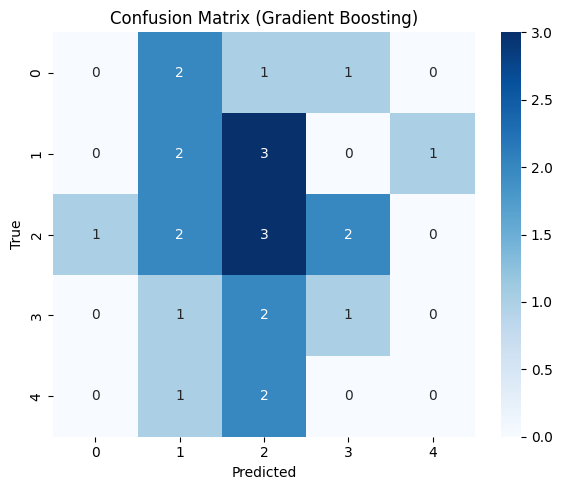

In [133]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 📥 Загрузка признаков
df = pd.read_csv("C:/Users/maxim/p2025/hand_features_all.csv")

# 🎯 Признаки и метки
X = df.drop(columns=["label", "video"])
y = df["label"]

# ⚖️ Масштабирование признаков
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ✂️ Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, stratify=y, test_size=0.2, random_state=42
)

# 📊 Вычисление весов классов
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

# 🔍 Подбор гиперпараметров (опционально)
param_grid = {
    'n_estimators': [150, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3, 4]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

# 🧠 Обучение модели с учетом весов
grid.fit(X_train, y_train, sample_weight=sample_weights)
best_model = grid.best_estimator_

# 🧾 Предсказания и отчет
y_pred = best_model.predict(X_test)
print("Best params:", grid.best_params_)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))

# 📉 Матрица ошибок
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=best_model.classes_, yticklabels=best_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Gradient Boosting)")
plt.tight_layout()
plt.show()


In [134]:
import numpy as np
from sklearn.linear_model import RANSACRegressor
from sklearn.decomposition import PCA
from scipy.signal import savgol_filter, find_peaks
from scipy.stats import entropy

def calc_hand_normal_pca(kp: np.ndarray) -> np.ndarray:
    """Нормаль к плоскости ладони через PCA по ключевым точкам ладони (0..20)."""
    # Используем наиболее стабильные точки: запястье (0), основания пальцев (1-4,5-8,...)
    if np.isnan(kp).any():
        valid = ~np.isnan(kp).any(axis=1)
        if np.sum(valid) < 3:
            return np.array([np.nan, np.nan, np.nan])
        points = kp[valid]
    else:
        points = kp

    # Отцентрируем
    points_centered = points - np.mean(points, axis=0)
    pca = PCA(n_components=3)
    pca.fit(points_centered)
    # Нормаль — третья компонента (наименьшая дисперсия)
    normal = pca.components_[-1]
    # Приведём к единичному
    norm = np.linalg.norm(normal)
    if norm == 0:
        return np.array([np.nan, np.nan, np.nan])
    return normal / norm

def unwrap_angle_sequence(angles: np.ndarray) -> np.ndarray:
    """Разворачивает углы, чтобы избежать скачков ±180°."""
    return np.unwrap(np.deg2rad(angles))

def compute_rotation_angle(normals: np.ndarray, reference: np.ndarray = None) -> np.ndarray:
    """
    Угол между текущей нормалью и локальной базовой ориентацией.
    Если reference предоставлен как скользящая средняя нормалей, 
    тогда считаем угол между каждой нормалью и этой базовой.
    """
    # Если reference не задан — используем скользящую среднюю нормаль по фильтру
    if reference is None:
        # Простая скользящая средняя нормалей (каждая координата)
        window = max(3, len(normals)//20)  # адаптивно
        normals_smooth = np.copy(normals)
        for i in range(3):
            coord = normals[:, i]
            # заменяем nan линейной интерполяцией
            nans = np.isnan(coord)
            if np.any(nans):
                valid_x = np.where(~nans)[0]
                if len(valid_x) >= 2:
                    coord[nans] = np.interp(np.where(nans)[0], valid_x, coord[~nans])
            normals_smooth[:, i] = savgol_filter(coord, window_length=window + (1 - window % 2), polyorder=2, mode='nearest')
        reference = np.tile(np.mean(normals_smooth, axis=0), (len(normals), 1))

    angles = []
    for n, ref in zip(normals, reference):
        if np.any(np.isnan(n)) or np.any(np.isnan(ref)):
            angles.append(np.nan)
            continue
        dot = np.clip(np.dot(n, ref), -1.0, 1.0)
        angle_rad = np.arccos(dot)
        angle_deg = np.degrees(angle_rad)
        angles.append(angle_deg)
    return np.array(angles)

def smooth_signal(x: np.ndarray, window_length: int = 9, polyorder: int = 2) -> np.ndarray:
    """Сглаживание с обработкой NaN."""
    x_clean = np.copy(x)
    nans = np.isnan(x_clean)
    if np.any(nans):
        valid_x = np.where(~nans)[0]
        if len(valid_x) >= 2:
            x_clean[nans] = np.interp(np.where(nans)[0], valid_x, x_clean[~nans])
        else:
            return x  # нечего сглаживать
    # window_length должно быть нечётным и <= len
    wl = min(window_length, len(x_clean))
    if wl % 2 == 0:
        wl -= 1
    if wl < 3:
        return x_clean
    try:
        return savgol_filter(x_clean, window_length=wl, polyorder=polyorder, mode='interp')
    except Exception:
        return x_clean

def calc_cycle_features(angle_unwrapped: np.ndarray, fps: float):
    """Извлекает цикловые характеристики из развёрнутого углового сигнала."""
    # Производная = угловая скорость
    angular_velocity = np.gradient(angle_unwrapped) * fps  # rad/sec
    # Ищем экстремумы по углу (пики и впадины) -> начало/конец циклов
    # Приводим обратно к градусам для пиков
    angle_deg = np.rad2deg(angle_unwrapped)
    # Сглаживание для устойчивости пиков
    angle_smooth = smooth_signal(angle_deg, window_length=11)
    peaks, _ = find_peaks(angle_smooth, distance=int(0.5 * fps))  # минимум полсекунды между циклами
    troughs, _ = find_peaks(-angle_smooth, distance=int(0.5 * fps))
    extrema = np.sort(np.concatenate([peaks, troughs]))

    intervals = []
    amplitudes = []
    for i in range(1, len(extrema)):
        interval = (extrema[i] - extrema[i - 1]) / fps
        intervals.append(interval)
        amp = abs(angle_smooth[extrema[i]] - angle_smooth[extrema[i - 1]])
        amplitudes.append(amp)

    intervals = np.array(intervals)
    amplitudes = np.array(amplitudes)

    # Ритмичность: CV интервалов
    coordination = np.std(intervals) / np.mean(intervals) if len(intervals) > 1 and np.mean(intervals) != 0 else np.nan
    # Энтропия распределения интервалов
    if len(intervals) >= 3:
        # биннинг
        hist, _ = np.histogram(intervals, bins=min(5, len(intervals)), density=True)
        hist = hist[hist > 0]
        ent = entropy(hist)
    else:
        ent = np.nan

    cycle_count = len(intervals)
    freq = 1.0 / np.mean(intervals) if len(intervals) > 0 and np.mean(intervals) != 0 else 0

    return {
        "cycle_count": cycle_count,
        "frequency_hz": freq,
        "coordination_cv": coordination,
        "interval_entropy": ent,
        "amplitude_mean": np.nanmean(amplitudes) if amplitudes.size else np.nan,
        "amplitude_max": np.nanmax(amplitudes) if amplitudes.size else np.nan,
        "amplitude_std": np.nanstd(amplitudes) if amplitudes.size else np.nan,
        "angular_velocity_mean": np.nanmean(np.abs(angular_velocity)),
        "angular_velocity_max": np.nanmax(np.abs(angular_velocity)),
    }

def detect_freezes(angular_velocity: np.ndarray, fps: float, vel_threshold: float = 5.0, min_duration_sec: float = 0.5):
    """
    Длительное “застывание”: периоды, где угловая скорость ниже порога.
    Возвращает максимальную и среднюю длительность таких пауз.
    """
    low_motion = np.abs(angular_velocity) < vel_threshold  # в радианах/сек
    durations = []
    current = 0
    for flag in low_motion:
        if flag:
            current += 1
        else:
            if current > 0:
                durations.append(current / fps)
                current = 0
    if current > 0:
        durations.append(current / fps)
    durations = np.array(durations)
    long_freezes = durations[durations >= min_duration_sec]
    return {
        "max_freeze_duration": np.nanmax(long_freezes) if long_freezes.size else 0.0,
        "mean_freeze_duration": np.nanmean(long_freezes) if long_freezes.size else 0.0,
        "freeze_count": len(long_freezes)
    }

def extract_hand_features_from_npy(npy_path: str, fps: float = 30.0) -> dict:
    keypoints3d = np.load(npy_path)  # (T, 21, 3)
    normals = np.array([calc_hand_normal_pca(frame) for frame in keypoints3d])

    # Угол вращения и фаза
    angles = compute_rotation_angle(normals)  # градусы
    angle_unwrapped = unwrap_angle_sequence(angles)  # радианы

    # Сглаженный фазовый сигнал
    angle_smooth = smooth_signal(np.rad2deg(angle_unwrapped), window_length=11)
    angle_unwrapped_smooth = np.deg2rad(angle_smooth)

    # Цикловые признаки
    cycle_feats = calc_cycle_features(angle_unwrapped_smooth, fps)

    # Угловая скорость
    angular_velocity = np.gradient(angle_unwrapped_smooth) * fps  # rad/sec

    # Freezes
    freeze_feats = detect_freezes(angular_velocity, fps)

    # Тренд амплитуд (устойчивый) через RANSAC
    amps = []
    # для тренда берём последовательность амплитуд между экстремумами
    # (внутри calc_cycle_features они уже рассчитаны; можно повторно извлечь)
    # Здесь для простоты: используем amplitude_mean последовательности как y
    if not np.isnan(cycle_feats["amplitude_mean"]):
        y = np.array([cycle_feats["amplitude_mean"]])
        trend = np.nan  # слишком мало данных для тренда, можно расширить по циклам
    else:
        trend = np.nan

    # Стабильность нормалей
    normal_variability = np.nanstd(normals, axis=0)
    normal_variability_norm = np.linalg.norm(normal_variability)

    features = {
        # базовые
        "frequency_hz": cycle_feats["frequency_hz"],
        "cycle_count": cycle_feats["cycle_count"],
        "coordination_cv": cycle_feats["coordination_cv"],
        "interval_entropy": cycle_feats["interval_entropy"],
        "amplitude_mean": cycle_feats["amplitude_mean"],
        "amplitude_max": cycle_feats["amplitude_max"],
        "amplitude_std": cycle_feats["amplitude_std"],
        "angular_velocity_mean": cycle_feats["angular_velocity_mean"],
        "angular_velocity_max": cycle_feats["angular_velocity_max"],
        # freeze
        "max_freeze_duration": freeze_feats["max_freeze_duration"],
        "mean_freeze_duration": freeze_feats["mean_freeze_duration"],
        "freeze_count": freeze_feats["freeze_count"],
        # стабильность ориентации
        "normal_variability": normal_variability_norm,
        # (если есть) trend placeholder
        "amplitude_trend": trend,
    }

    return features


In [135]:
import pathlib
import pandas as pd

def build_feature_df(base_dir: str, fps: float = 30.0):
    base = pathlib.Path(base_dir)
    rows = []
    for label_folder in sorted(base.iterdir()):
        if not label_folder.is_dir():
            continue
        label = int(label_folder.name)
        for npy_file in label_folder.glob("*.npy"):
            feats = extract_hand_features_from_npy(str(npy_file), fps)
            feats.update({"video": str(npy_file), "label": label})
            rows.append(feats)
    return pd.DataFrame(rows)

df = build_feature_df(r"C:\Users\maxim\p2025\output_keypoints", fps=30.0)
df.to_csv("hand_features_enhanced.csv", index=False)


In [138]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Загрузка признаков
df = pd.read_csv("C:/Users/maxim/p2025/hand_features_enhanced.csv")
X = df.drop(columns=["label", "video"])
y = df["label"]
print(df.isna().sum())
X = df.drop(columns=["label", "video", "amplitude_trend"])


frequency_hz               0
cycle_count                0
coordination_cv            0
interval_entropy           0
amplitude_mean             0
amplitude_max              0
amplitude_std              0
angular_velocity_mean      0
angular_velocity_max       0
max_freeze_duration        0
mean_freeze_duration       0
freeze_count               0
normal_variability         0
amplitude_trend          122
video                      0
label                      0
dtype: int64


              precision    recall  f1-score   support

           0      0.167     0.250     0.200         4
           1      0.429     0.500     0.462         6
           2      0.444     0.500     0.471         8
           3      0.000     0.000     0.000         4
           4      0.000     0.000     0.000         3

    accuracy                          0.320        25
   macro avg      0.208     0.250     0.226        25
weighted avg      0.272     0.320     0.293        25



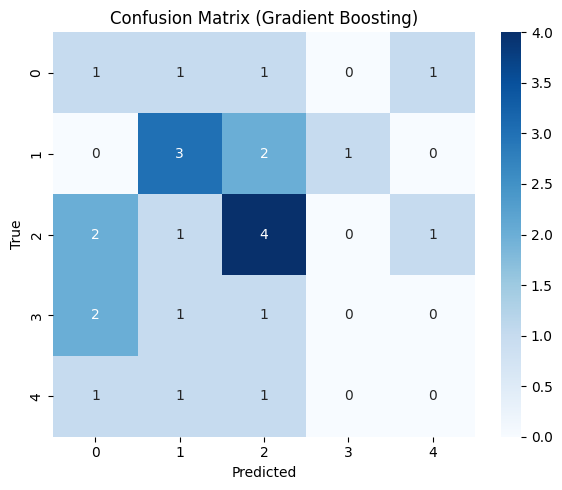

In [139]:
# 2. Нормализация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, stratify=y, test_size=0.2, random_state=42
)

# 4. Обучение модели
clf = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
clf.fit(X_train, y_train)

# 5. Предсказание
y_pred = clf.predict(X_test)

# 6. Отчёт
print(classification_report(y_test, y_pred, digits=3))

# 7. Матрица ошибок
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Gradient Boosting)")
plt.tight_layout()
plt.show()


# Удалить ненужное

In [21]:
import os
import glob

# Указываем пути
video_dir = r"C:\Users\maxim\p2025\hands_cut 1"
keypoints_base_dir = r"C:\Users\maxim\p2025\output_keypoints 1"

# Безопасный режим (только вывод, без удаления)
dry_run = True  # ← поменяй на False, чтобы включить удаление

# Получаем все mp4-файлы из подпапок, сохраняем базовые имена (без .mp4)
video_files = {
    os.path.splitext(os.path.basename(path))[0]
    for path in glob.glob(os.path.join(video_dir, "**", "*.mp4"), recursive=True)
}

print(f"Найдено {len(video_files)} видеофайлов.")

deleted_files = []

# Проходим по папкам с кейпоинтами (0,1,2,3,...)
for subfolder in os.listdir(keypoints_base_dir):
    subfolder_path = os.path.join(keypoints_base_dir, subfolder)
    if not os.path.isdir(subfolder_path):
        continue

    for filename in os.listdir(subfolder_path):
        if filename.endswith(("_3dkeypoints.csv", "_3dkeypoints.npy")):
            base_name = filename.split("_3dkeypoints")[0]

            if base_name not in video_files:
                file_path = os.path.join(subfolder_path, filename)
                deleted_files.append(file_path)
                if dry_run:
                    print(f"[dry-run] Удалился бы: {file_path}")
                else:
                    os.remove(file_path)
                    print(f"Удалён: {file_path}")

print()
if dry_run:
    print(f"[dry-run] Всего было бы удалено: {len(deleted_files)} файлов.")
else:
    print(f"Удалено файлов: {len(deleted_files)}")


Удалено 418 файлов.


# Финальный блок для вычисления всех точек

In [24]:
import mmpose
from mmpose.apis import inference_topdown, init_model
from IPython.display import display, Image
import pathlib
import cv2
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from mmpose.registry import VISUALIZERS
from mmpose.structures import merge_data_samples
import tqdm.notebook as tqdm
from enum import Enum

In [5]:
hand_config_path = "C:/Users/maxim/p2025/mmpose/configs/hand_3d_keypoint/internet/interhand3d/internet_res50_4xb16-20e_interhand3d-256x256.py"
hand_checkpoint = "https://download.openmmlab.com/mmpose/hand3d/internet/res50_intehand3dv1.0_all_256x256-42b7f2ac_20210702.pth"
model_hand = init_model(hand_config_path, hand_checkpoint, device="cpu")

Loads checkpoint by http backend from path: https://download.openmmlab.com/mmpose/hand3d/internet/res50_intehand3dv1.0_all_256x256-42b7f2ac_20210702.pth


C:\Users\maxim\anaconda3\envs\mmpose_cpu\lib\site-packages\mmpose\datasets\datasets\utils.py:102: UserWarning: The metainfo config file "configs/_base_/datasets/interhand3d.py" does not exist. A matched config file "C:\Users\maxim\anaconda3\envs\mmpose_cpu\lib\site-packages\mmpose\.mim\configs\_base_\datasets\interhand3d.py" will be used instead.
  warnings.warn(


In [6]:
cut_dataset_path = pathlib.Path("hands_cut")

In [7]:
def hand_estimation(video_path: str, model) -> list:
    """Прогоняет hand estimation на видео и возвращает список результатов (по кадрам)."""
    results = []
    pbar = tqdm.tqdm()
    video = cv2.VideoCapture(str(video_path))
    while True:
        ret, frame = video.read()
        if not ret:
            break
        batch_results = inference_topdown(model, frame)
        merged = merge_data_samples(batch_results)
        results.append(merged)
        pbar.update(1)
    pbar.close()
    return results


In [8]:
def extract_3d_keypoints(results: list) -> np.ndarray:
    """
    Извлекает 3D ключевые точки одной (реальной) руки из результатов.
    Работает с sample.pred_instances.keypoints, которые уже в NumPy.
    """
    keypoints_all = []
    for sample in results:
        try:
            kp3d = sample.pred_instances.keypoints[0]  # уже NumPy, shape (42, 3)

            left = kp3d[:21]
            right = kp3d[21:]

            # Выбираем руку с большим числом ненулевых координат
            left_valid = np.sum(~np.isnan(left))
            right_valid = np.sum(~np.isnan(right))

            if right_valid >= left_valid:
                keypoints_all.append(right)
            else:
                keypoints_all.append(left)

        except Exception as e:
            print(f"Ошибка в кадре: {e}")
            keypoints_all.append(np.full((21, 3), np.nan))
    return np.array(keypoints_all)


In [9]:
def save_keypoints_to_npy(keypoints3d: np.ndarray, out_path: str):
    np.save(out_path, keypoints3d)

In [10]:
def save_keypoints_to_csv(keypoints3d: np.ndarray, out_path: str):
    """
    Сохраняет 3D ключевые точки в .csv формате. Каждая строка — один кадр.
    Формат: frame,x_0,y_0,z_0,...,x_20,y_20,z_20
    """
    n_frames, n_joints, _ = keypoints3d.shape
    rows = []
    for frame_idx in range(n_frames):
        row = {"frame": frame_idx}
        for joint_idx in range(n_joints):
            x, y, z = keypoints3d[frame_idx, joint_idx]
            row[f"x_{joint_idx}"] = x
            row[f"y_{joint_idx}"] = y
            row[f"z_{joint_idx}"] = z
        rows.append(row)
    df = pd.DataFrame(rows)
    df.to_csv(out_path, index=False)


In [11]:
def process_video(video_path: str, output_dir: str, model) -> None:
    """
    Обрабатывает видео: извлекает 3D ключевые точки и сохраняет их.
    """
    output_dir = pathlib.Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    print(f"Обработка: {video_path}")
    results = hand_estimation(video_path, model)
    keypoints3d = extract_3d_keypoints(results)

    base_name = pathlib.Path(video_path).stem
    npy_path = output_dir / f"{base_name}_3dkeypoints.npy"
    csv_path = output_dir / f"{base_name}_3dkeypoints.csv"

    save_keypoints_to_npy(keypoints3d, npy_path)
    save_keypoints_to_csv(keypoints3d, csv_path)
    print(f"Сохранено: {npy_path} и {csv_path}")


In [12]:
import os
import pathlib

video_root = "hands_cut"
output_root = "output_keypoints 0"

def batch_process_all_videos(video_root: str, output_root: str, model) -> None:
    video_root = pathlib.Path(video_root)
    output_root = pathlib.Path(output_root)
    output_root.mkdir(parents=True, exist_ok=True)

    for class_dir in video_root.iterdir():
        if not class_dir.is_dir():
            continue

        output_class_dir = output_root / class_dir.name
        output_class_dir.mkdir(parents=True, exist_ok=True)

        for video_file in class_dir.glob("*.mp4"):
            print(f"Обработка: {video_file}")
            try:
                results = hand_estimation(str(video_file), model)
                keypoints3d = extract_3d_keypoints(results)

                base_name = video_file.stem
                npy_path = output_class_dir / f"{base_name}_3dkeypoints.npy"
                csv_path = output_class_dir / f"{base_name}_3dkeypoints.csv"

                save_keypoints_to_npy(keypoints3d, str(npy_path))
                save_keypoints_to_csv(keypoints3d, str(csv_path))
                print(f"Сохранено: {npy_path.name}, {csv_path.name}")
            except Exception as e:
                print(f"Ошибка на {video_file.name}: {e}")

In [13]:
import os
import pathlib

video_root = "hands_cut"
output_root = "output_keypoints 0"

def batch_process_all_videos(video_root: str, output_root: str, model) -> None:
    video_root = pathlib.Path(video_root)
    output_root = pathlib.Path(output_root)
    output_root.mkdir(parents=True, exist_ok=True)

    for class_dir in video_root.iterdir():
        if not class_dir.is_dir():
            continue

        output_class_dir = output_root / class_dir.name
        output_class_dir.mkdir(parents=True, exist_ok=True)

        for video_file in class_dir.glob("*.mp4"):
            base_name = video_file.stem
            npy_path = output_class_dir / f"{base_name}_3dkeypoints.npy"
            csv_path = output_class_dir / f"{base_name}_3dkeypoints.csv"

            # Пропуск, если уже обработано
            if npy_path.exists() and csv_path.exists():
                print(f"Пропущено (уже обработано): {video_file.name}")
                continue

            print(f"Обработка: {video_file}")
            try:
                results = hand_estimation(str(video_file), model)
                keypoints3d = extract_3d_keypoints(results)

                save_keypoints_to_npy(keypoints3d, str(npy_path))
                save_keypoints_to_csv(keypoints3d, str(csv_path))
                print(f"Сохранено: {npy_path.name}, {csv_path.name}")
            except Exception as e:
                print(f"Ошибка на {video_file.name}: {e}")


In [14]:
batch_process_all_videos("hands_cut", "output_keypoints 0", model_hand)

Обработка: hands_cut\0\100_10052025191422_0315b142-246b-11ed-a221-e82aea2c97f4.mp4


0it [00:00, ?it/s]

Сохранено: 100_10052025191422_0315b142-246b-11ed-a221-e82aea2c97f4_3dkeypoints.npy, 100_10052025191422_0315b142-246b-11ed-a221-e82aea2c97f4_3dkeypoints.csv
Обработка: hands_cut\0\10178_11052025093016_f2c94ce2-6a49-11ed-ab19-e82aea2c97f4.mp4


0it [00:00, ?it/s]

Сохранено: 10178_11052025093016_f2c94ce2-6a49-11ed-ab19-e82aea2c97f4_3dkeypoints.npy, 10178_11052025093016_f2c94ce2-6a49-11ed-ab19-e82aea2c97f4_3dkeypoints.csv
Обработка: hands_cut\0\1023_10052025200029_968a1da4-aa89-11ec-be35-e82aea2c97f4.mp4


...

Сохранено: 144_10052025190532_b981e876-2f47-11ed-865a-c86000e163af_3dkeypoints.npy, 144_10052025190532_b981e876-2f47-11ed-865a-c86000e163af_3dkeypoints.csv
Обработка: hands_cut\3\149_10052025185153_0faade1e-2501-11ed-a891-c86000e163af.mp4


0it [00:00, ?it/s]

Сохранено: 149_10052025185153_0faade1e-2501-11ed-a891-c86000e163af_3dkeypoints.npy, 149_10052025185153_0faade1e-2501-11ed-a891-c86000e163af_3dkeypoints.csv
Обработка: hands_cut\3\149_10052025190600_c0bd496e-397f-11ed-b717-c86000e163af.mp4


0it [00:00, ?it/s]

Сохранено: 149_10052025190600_c0bd496e-397f-11ed-b717-c86000e163af_3dkeypoints.npy, 149_10052025190600_c0bd496e-397f-11ed-b717-c86000e163af_3dkeypoints.csv
